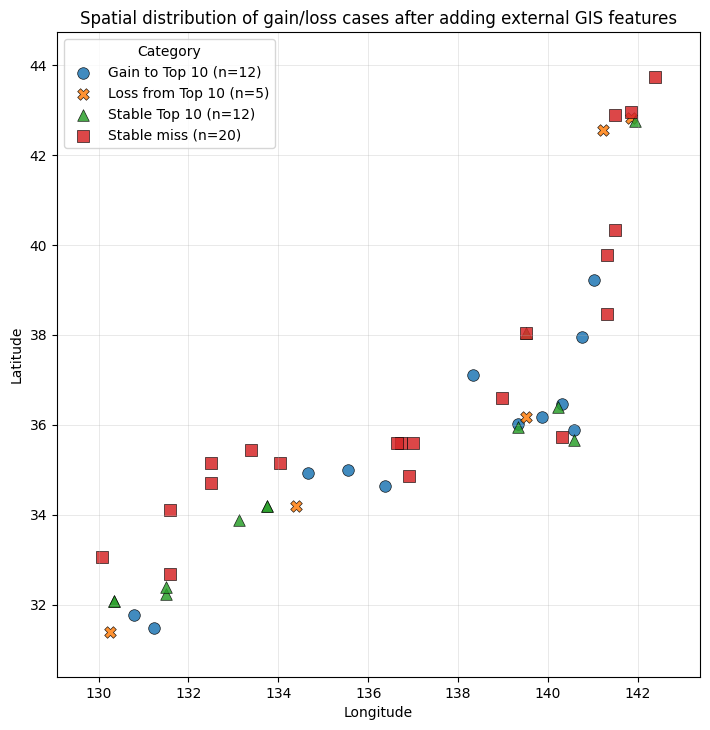

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("19_v2_map_ready_external_gis_gain_loss_cases.csv")
df = pd.read_csv(csv_path)

category_order = [
    "gain_to_top10",
    "loss_from_top10",
    "stable_top10",
    "stable_miss",
]

label_map = {
    "gain_to_top10": "Gain to Top 10",
    "loss_from_top10": "Loss from Top 10",
    "stable_top10": "Stable Top 10",
    "stable_miss": "Stable miss",
}

marker_map = {
    "gain_to_top10": "o",
    "loss_from_top10": "X",
    "stable_top10": "^",
    "stable_miss": "s",
}

plot_df = df.dropna(subset=["grid_lon", "grid_lat", "gis_gain_category"]).copy()
plot_df = plot_df[plot_df["gis_gain_category"].isin(category_order)]

fig, ax = plt.subplots(figsize=(7.2, 8.4))

for cat in category_order:
    sub = plot_df[plot_df["gis_gain_category"] == cat]
    ax.scatter(
        sub["grid_lon"],
        sub["grid_lat"],
        label=f"{label_map[cat]} (n={len(sub)})",
        marker=marker_map[cat],
        s=70,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.5,
    )

ax.set_title("Spatial distribution of gain/loss cases after adding external GIS features")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend(title="Category", loc="best", frameon=True)

lon_min, lon_max = plot_df["grid_lon"].min(), plot_df["grid_lon"].max()
lat_min, lat_max = plot_df["grid_lat"].min(), plot_df["grid_lat"].max()
ax.set_xlim(lon_min - 1.0, lon_max + 1.0)
ax.set_ylim(lat_min - 1.0, lat_max + 1.0)

plt.tight_layout()
plt.savefig("figure5_external_gis_gain_loss_map.png", dpi=300, bbox_inches="tight")
plt.savefig("figure5_external_gis_gain_loss_map.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# 必要なら最初に実行
!pip -q install geopandas pyogrio

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. Input: final v7 output
# =========================
candidate_paths = [
    Path(
        "/content/drive/MyDrive/avian_influenza_project/processed/"
        "model_outputs_riskmap_eval/"
        "14_v7_map_ready_external_gis_gain_loss_cases.csv"
    ),
    Path("14_v7_map_ready_external_gis_gain_loss_cases.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "14_v7_map_ready_external_gis_gain_loss_cases.csv was not found.\n"
        "Checked:\n"
        + "\n".join(str(p) for p in candidate_paths)
    )

df = pd.read_csv(csv_path)

required_cols = {
    "grid_lon",
    "grid_lat",
    "top10_transition",
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}\n"
        f"Available columns: {df.columns.tolist()}"
    )

plot_df = df.dropna(
    subset=["grid_lon", "grid_lat", "top10_transition"]
).copy()

# =========================
# 2. Final v7 categories
# =========================
category_order = [
    "Gain to Top 10",
    "Loss from Top 10",
    "Stable Top 10",
    "Stable miss",
]

label_map = {
    "Gain to Top 10": "Gain to Top 10%",
    "Loss from Top 10": "Loss from Top 10%",
    "Stable Top 10": "Stable Top 10%",
    "Stable miss": "Stable miss",
}

color_map = {
    "Gain to Top 10": "#1f77b4",
    "Loss from Top 10": "#ff7f0e",
    "Stable Top 10": "#2ca02c",
    "Stable miss": "#d62728",
}

marker_map = {
    "Gain to Top 10": "o",
    "Loss from Top 10": "X",
    "Stable Top 10": "^",
    "Stable miss": "s",
}

expected_counts = {
    "Gain to Top 10": 12,
    "Loss from Top 10": 4,
    "Stable Top 10": 7,
    "Stable miss": 26,
}

unexpected_categories = sorted(
    set(plot_df["top10_transition"]) - set(category_order)
)
if unexpected_categories:
    raise ValueError(
        "Unexpected top10_transition values: "
        f"{unexpected_categories}"
    )

observed_counts = (
    plot_df["top10_transition"]
    .value_counts()
    .reindex(category_order, fill_value=0)
    .to_dict()
)

print("Input:", csv_path)
print("Observed category counts:", observed_counts)

if observed_counts != expected_counts:
    raise ValueError(
        "The category counts do not match the final v7 results.\n"
        f"Expected: {expected_counts}\n"
        f"Observed: {observed_counts}"
    )

if len(plot_df) != 49:
    raise ValueError(
        f"Expected 49 strict first-occurrence-like events, "
        f"but found {len(plot_df)}."
    )

# =========================
# 3. Convert event points to GeoDataFrame
# =========================
gdf_points = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(
        plot_df["grid_lon"],
        plot_df["grid_lat"],
    ),
    crs="EPSG:4326",
)

# =========================
# 4. Load Japan map from Natural Earth
# =========================
countries_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_0_countries.zip"
)
world = gpd.read_file(countries_url)
japan = world[world["ADMIN"] == "Japan"].copy()

admin1_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_1_states_provinces.zip"
)
admin1 = gpd.read_file(admin1_url)

if "adm0_name" in admin1.columns:
    japan_admin1 = admin1[
        admin1["adm0_name"] == "Japan"
    ].copy()
elif "admin" in admin1.columns:
    japan_admin1 = admin1[
        admin1["admin"] == "Japan"
    ].copy()
else:
    japan_admin1 = gpd.GeoDataFrame(
        geometry=[],
        crs="EPSG:4326",
    )

# =========================
# 5. Plot
# =========================
fig, ax = plt.subplots(figsize=(7.5, 8.8))

japan.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.8,
    zorder=1,
)

if len(japan_admin1) > 0:
    japan_admin1.boundary.plot(
        ax=ax,
        color="lightgray",
        linewidth=0.4,
        zorder=2,
    )

for category in category_order:
    sub = gdf_points[
        gdf_points["top10_transition"] == category
    ]

    # Make the loss marker slightly larger and thicker
    # because only four loss cases are present.
    marker_size = 95 if category == "Loss from Top 10" else 65
    line_width = 1.0 if category == "Loss from Top 10" else 0.4

    sub.plot(
        ax=ax,
        marker=marker_map[category],
        color=color_map[category],
        edgecolor="black",
        linewidth=line_width,
        markersize=marker_size,
        label=(
            f"{label_map[category]} "
            f"(n = {len(sub)})"
        ),
        zorder=6 if category == "Loss from Top 10" else 5,
    )

ax.set_xlim(128.5, 146.5)
ax.set_ylim(30.0, 46.0)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Spatial distribution of gain and loss cases after adding "
    "deduplicated external GIS and land-use features"
)

ax.legend(
    title="Category",
    loc="upper left",
    frameon=True,
    fontsize=9,
    title_fontsize=9,
)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()

# =========================
# 6. Save beside the input CSV
# =========================
output_dir = csv_path.parent

out_png = (
    output_dir
    / "figure5_external_gis_gain_loss_japan_map_14v7.png"
)
out_pdf = (
    output_dir
    / "figure5_external_gis_gain_loss_japan_map_14v7.pdf"
)

plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    out_pdf,
    bbox_inches="tight",
)
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)
